# Notebook for running characterizing spots on BOT data.

Initially written 10 Jan 2020 by Craig Lage.\
Looking at running with the forward modeling.\

In [1]:
! eups list -s | grep lsst_distrib

lsst_distrib          19.0.0+20  	current d_2020_01_08 setup


In [2]:
import sys, os, glob, time
import pickle as pkl
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from scipy.optimize import fmin_powell
from scipy.special import erf
sys.path.append(os.path.realpath('/home/cslage/alternate_branches/Poisson_CCD/pysrc/forward_model_varying_i'))
import forward

import eups
from lsst.daf.persistence import Butler
import lsst.afw.image as afwImage
import lsst.geom as geom
from lsst.daf.persistence import Butler
from lsst.ip.isr.isrTask import IsrTask, IsrTaskConfig
from lsst.ip.isr.isrFunctions import brighterFatterCorrection
from lsst.meas.algorithms import SourceDetectionTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask, CharacterizeImageConfig
from lsst.geom import Point2I, Box2I

In [31]:
# Classes to put the data
class Array2dSet:
    def __init__(self,xmin,xmax,nx,ymin,ymax,ny,nstamps):
        # This packages up a set of nstamps postage stamp images,
        # each image of which is nx * ny pixels
        self.nx=nx
        self.ny=ny
        self.nstamps=nstamps

        self.xmin=xmin
        self.ymin=ymin
        
        self.xmax=xmax
        self.ymax=ymax
        
        self.dx=(xmax-xmin)/nx
        self.dy=(ymax-ymin)/ny
        
        self.x=np.linspace(xmin+self.dx/2,xmax-self.dx/2,nx)
        self.y=np.linspace(ymin+self.dy/2,ymax-self.dy/2,ny)

        self.data=np.zeros([nx,ny,nstamps])
        self.xoffset=np.zeros([nstamps])
        self.yoffset=np.zeros([nstamps])
        self.imax=np.zeros([nstamps])


def BuildSpotList(array, x_centroids, y_centroids, nx, ny):
    stampxmin = -(int(nx/2)+0.5)
    stampxmax = -stampxmin
    stampymin = -(int(ny/2)+0.5)
    stampymax = -stampymin
    numspots = len(x_centroids)
    spotlist = Array2dSet(stampxmin,stampxmax,nx,stampymin,stampymax,ny,numspots)
    n=0
    for xcen,ycen in zip(x_centroids, y_centroids):
        xint = int(round(xcen))
        yint = int(round(ycen))
        xmin = xint - int(nx/2)
        xmax = xint + int(nx/2) + 1
        ymin = yint - int(ny/2)
        ymax = yint + int(ny/2) + 1
        stamp = array[ymin:ymax, xmin:xmax]
        # Now recenter to the spot maximum
        ind = np.unravel_index(np.argmax(stamp, axis=None), stamp.shape)
        yint = yint + ind[0] - int((ny-1) / 2)
        xint = xint + ind[1] - int((nx-1) / 2)
        xmin = xint - int(nx/2)
        xmax = xint + int(nx/2) + 1
        ymin = yint - int(ny/2)
        ymax = yint + int(ny/2) + 1
        stamp = array[ymin:ymax, xmin:xmax]
        xsum = 0.0
        ysum = 0.0
        datasum = 0.0
        
        for i in range(nx):
            for j in range(ny):
                spotlist.data[i,j,n] = float(stamp[j,i])  

        for i in range(nx):
            for j in range(ny):
                spotlist.data[i,j,n] = float(stamp[j,i])                    
                ysum += spotlist.y[j] * spotlist.data[i,j,n]
                xsum += spotlist.x[i] * spotlist.data[i,j,n]
                datasum += spotlist.data[i,j,n]
        xoff = xsum / datasum
        yoff = ysum / datasum
        spotlist.xoffset[n] = xoff
        spotlist.yoffset[n] = yoff
        
        n += 1
    return spotlist

def FOM(params):
    [sigmax, sigmay] = params
    result = forward.forward(spotlist,sigmax,sigmay)
    return result

def PyFOM(params):
    # Modified this to also fit for the X,Y offsets
    fom = 0.0
    [Imax, sigmax, sigmay, xoff, yoff] = params
    area=np.zeros([spotlist.nx,spotlist.ny])
   
    for spot in range(spotlist.nstamps):
        for ii in range(spotlist.nx):
            for jj in range(spotlist.ny):
                xl = spotlist.x[ii] - xoff - 0.5
                xh = xl + 1.0
                yl = spotlist.y[jj] - yoff - 0.5
                yh = yl + 1.0
                area[ii,jj] = Area(xl, xh, yl, yh, sigmax, sigmay, Imax)
                fom += np.square(area[ii,jj]-spotlist.data[ii,jj,spot])
    return fom


def Area(xl, xh, yl, yh, sigmax, sigmay, Imax):
    # Calculates how much of a 2D Gaussian falls within a rectangular box
    ssigx = np.sqrt(2.0) * sigmax
    ssigy = np.sqrt(2.0) * sigmay    
    I = (erf(xh/ssigx)-erf(xl/ssigx))*(erf(yh/ssigy)-erf(yl/ssigy))
    return Imax * I / 4.0

In [4]:
OUTPUT_DIR = '/project/cslage/BOT/ITL/'
raftName = 'R02'
detectorName = 'S02'
DETECTOR = 11

In [5]:
# This sets up the visits.  
starting_visit = 3019103102226
ending_visit = 3019103102366

visits = []
visit_1 = starting_visit
while visit_1 < ending_visit+1:
    visits.append(visit_1)
    visit_1 += 20 # Skipping the bias frames in between
visits.append(3019110100001)
starting_visit = 3019110100013
ending_visit = 3019110100093
visit_1 = starting_visit
while visit_1 < ending_visit+1:
    visits.append(visit_1)
    visit_1 += 20 # Skipping the bias frames in between
print(visits)
print(len(visits))

[3019103102226, 3019103102246, 3019103102266, 3019103102286, 3019103102306, 3019103102326, 3019103102346, 3019103102366, 3019110100001, 3019110100013, 3019110100033, 3019110100053, 3019110100073, 3019110100093]
14


In [6]:
# Now set up the isrConfig and charConfig 
# The master bias, flat, and dark images have already been created and ingested.
butler = Butler(OUTPUT_DIR)

isrConfig = IsrTaskConfig()
isrConfig.doLinearize = False
isrConfig.doBias = True
isrConfig.doFlat = True
isrConfig.doDark = True
isrConfig.doFringe = False
isrConfig.doDefect = False
isrConfig.doAddDistortionModel = False
isrConfig.doWrite = False
isrConfig.doBrighterFatter = False
isrConfig.doApplyGains = False
isrTask = IsrTask(config=isrConfig)

charConfig = CharacterizeImageConfig()
charConfig.installSimplePsf.fwhm = 1.0
charConfig.doMeasurePsf = False
charConfig.doApCorr = False
charConfig.doDeblend = False
charConfig.repair.doCosmicRay = True
charConfig.repair.doInterpolate = False   
charConfig.detection.background.binSize = 32
charConfig.detection.minPixels = 10
charTask = CharacterizeImageTask(config=charConfig)

/opt/lsst/software/stack/python/miniconda3-4.7.10/envs/lsst-scipipe-4d7b902/lib/python3.7/site-packages/ipykernel/__main__.py:12: FutureWarning: Config field doAddDistortionModel is deprecated: Camera geometry is incorporated when reading the raw files. This option no longer is used, and will be removed after v19.


/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

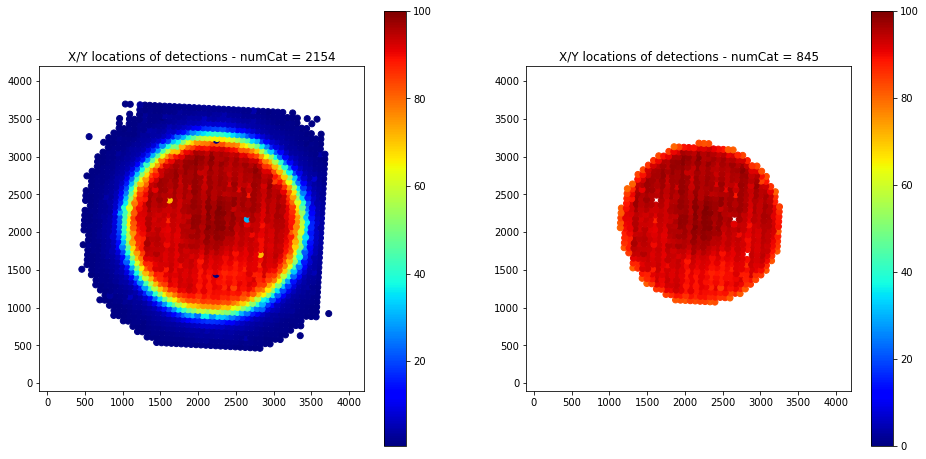

In [7]:
# First just try a single image with medium brightness
# Note that the spot flux varies by ~5X from center to edge
spot_visit=3019103102306
rawSpotDataRef = butler.dataRef('raw', detector=DETECTOR, visit=spot_visit)
postIsrSpot = isrTask.runDataRef(rawSpotDataRef).exposure
charResult = charTask.run(postIsrSpot)
spotCatalog = charResult.sourceCat
maxFlux = np.nanmax(spotCatalog['base_SdssShape_instFlux'])
minFluxRatio = 0.80
select = spotCatalog['base_SdssShape_instFlux'] > maxFlux * minFluxRatio
numCat = len(spotCatalog)
plt.figure(figsize=(16,8))
plt.subplot(1,2,1, aspect=1)
plt.title('X/Y locations of detections - numCat = %d'%numCat)
color = spotCatalog['base_SdssShape_instFlux'] / maxFlux * 100.0
plt.scatter(spotCatalog['base_SdssCentroid_x'],spotCatalog['base_SdssCentroid_y'],c=color, cmap=plt.cm.jet)
plt.colorbar()
plt.xlim(-100,4200)
plt.ylim(-100,4200)

spotCatalog  = spotCatalog.subset(select)
numCat = len(spotCatalog)
plt.subplot(1,2,2, aspect=1)
plt.title('X/Y locations of detections - numCat = %d'%numCat)
color = spotCatalog['base_SdssShape_instFlux'] / maxFlux * 100.0
norm = plt.Normalize(vmin=0.0, vmax=100.0)
plt.scatter(spotCatalog['base_SdssCentroid_x'],spotCatalog['base_SdssCentroid_y'],c=color, norm=norm, cmap=plt.cm.jet)
plt.colorbar()
plt.xlim(-100,4200)
plt.ylim(-100,4200)
plt.savefig(OUTPUT_DIR+"plots_forward/Spot_Intensities_10Jan20.pdf")

In [9]:
smallSelect = ((spotCatalog['base_SdssShape_instFlux'] > maxFlux * 0.99) & \
               (spotCatalog['base_SdssShape_instFlux'] < maxFlux * (1.0 - 1.0E-6)))
smallSpotCatalog = spotCatalog.subset(smallSelect)
maxSelect = spotCatalog['base_SdssShape_instFlux'] > maxFlux * (1.0 - 1.0E-6)
maxSpotCatalog = spotCatalog.subset(maxSelect)
print(len(maxSpotCatalog), len(smallSpotCatalog))

sep = np.sqrt(np.square(smallSpotCatalog['base_SdssCentroid_x'] - maxSpotCatalog['base_SdssCentroid_x'][0]) + \
              np.square(smallSpotCatalog['base_SdssCentroid_y'] - maxSpotCatalog['base_SdssCentroid_y'][0]))
print("Separation = %.2f pixels"%np.nanmin(sep))

1 9
Separation = 65.36 pixels


In [44]:
# Let's try running my forward modeling routine on a single set of several hundred stamps
spot_visit=3019103102306
rawSpotDataRef = butler.dataRef('raw', detector=DETECTOR, visit=spot_visit)
postIsrSpot = isrTask.runDataRef(rawSpotDataRef).exposure
charResult = charTask.run(postIsrSpot)
spotCatalog = charResult.sourceCat
maxFlux = np.nanmax(spotCatalog['base_SdssShape_instFlux'])
minFluxRatio = 0.80
select = spotCatalog['base_SdssShape_instFlux'] > maxFlux * minFluxRatio
spotCatalog  = spotCatalog.subset(select)
numCat = len(spotCatalog)
print(numCat)
idList = spotCatalog['id']

xs = spotCatalog['base_SdssCentroid_x']
ys = spotCatalog['base_SdssCentroid_y']
nx = ny = 25
spotlist = BuildSpotList(postIsrSpot.image.array, xs, ys, nx, ny)
print("nstamps = %d"%spotlist.nstamps)
param0 = [2.5,2.5]
args = ()

starttime = time.time()
Result = fmin_powell(FOM, param0, args)
elapsed = time.time() - starttime

print(Result, spotlist.imax[0], elapsed)
#print(spotlist.xoffset)
print(spotlist.nstamps)


/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

845
nstamps = 845
Optimization terminated successfully.
         Current function value: 92620222783.888397
         Iterations: 3
         Function evaluations: 74
[2.26496953 2.29074432] 825745.2200073873 5.144740343093872
845


960813.7191091691 0.1522357958618942
0.16369327669683087 -0.16081371710411244
Sum = 1113730.65, Max = 30042.0


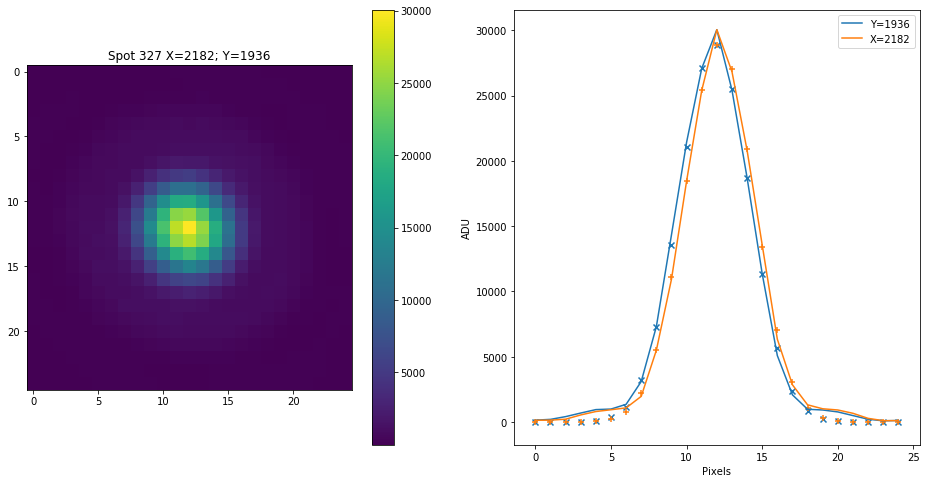

In [49]:
# Now just look at one of the spots
# to plot how well it fits
#spotCatalog = charResult.sourceCat
xs = spotCatalog['base_SdssCentroid_x']
ys = spotCatalog['base_SdssCentroid_y']
spotNum = 327
plotX = range(nx)
xCen = int(round(xs[spotNum]))
yCen = int(round(ys[spotNum]))
xMin = int(xCen - (nx-1)/2)
xMax = xMin + nx
yMin = int(yCen - (ny-1)/2)
yMax = yMin + ny


#sigmax = Result[1]
#sigmay = Result[2]
sigmax = Result[0]
sigmay = Result[1]

area=np.zeros([nx,ny])
Imax = spotlist.imax[spotNum]
for ii in range(nx):
    for jj in range(ny):
        xl = ii - int((nx-1)/2) - spotlist.xoffset[spotNum] - 0.5
        xh = xl + 1.0
        yl = jj - int((ny-1)/2) - spotlist.yoffset[spotNum] - 0.5
        yh = yl + 1.0
        area[ii,jj] = Area(xl, xh, yl, yh, sigmax, sigmay, Imax)
        #print(ii,jj,xl,xh,yl,yh)


print(Imax, area[4,4])
print(spotlist.xoffset[spotNum],spotlist.yoffset[spotNum])


plt.figure(figsize=(16,8))    
plt.subplot(1,2,1)
plt.title("Spot %d X=%d; Y=%d"%(spotNum,xCen,yCen))
#plt.imshow(postIsrSpot.image.array[yMin:yMax,xMin:xMax])
plt.imshow(spotlist.data[:,:,spotNum])
plt.colorbar()
plt.subplot(1,2,2)
#plt.plot(plotX, postIsrSpot.image.array[yCen,xMin:xMax], label = "Y=%d"%yCen)
#plt.plot(plotX, postIsrSpot.image.array[yMin:yMax,xCen], label = "X=%d"%xCen)
plt.plot(spotlist.data[int((nx-1)/2),:,spotNum], label = "Y=%d"%yCen)
plt.plot(spotlist.data[:,int((ny-1)/2),spotNum], label = "X=%d"%xCen)

plt.scatter(plotX,area[int((nx-1)/2),:], marker='x')
plt.scatter(plotX,area[:,int((ny-1)/2)], marker='+')
print("Sum = %.2f, Max = %.1f"%(spotlist.data[:,:,spotNum].sum(), spotlist.data[:,:,spotNum].max()))
plt.xlabel("Pixels")
plt.ylabel("ADU")
plt.legend()
plt.savefig(OUTPUT_DIR+"plots_forward/Spot_Profile_FOM_%d_%d_10Jan20.pdf"%(spot_visit, spotNum))

In [51]:
# Now we try running on all of the spot images

minSizeX = 4.0
maxSizeX = 7.0
minSizeY = 4.0
maxSizeY = 7.0
minX = minY = 1000
maxX = maxY = 3500
minFluxRatio = 0.80
nx = ny = 25
param0 = [2.5,2.5]
args = ()

byamp_results = []
byamp_corrected_results = []
for i, spot_visit in enumerate(visits):
    if i == 7:
        numVisits = 8
    elif i == 8:
        numVisits = 12
    else:
        numVisits = 20
    numVisits = 2
    for do_bf_corr in [False, True]:
        isrConfig.doBrighterFatter = do_bf_corr
        isrTask = IsrTask(config=isrConfig)
        x2 = []
        y2 = []
        flux = []
        numspots = 0
        for j in range(numVisits):
            sub_visit = spot_visit + j
            rawSpotDataRef = butler.dataRef('raw', detector=DETECTOR, visit=sub_visit)
            postIsrSpot = isrTask.runDataRef(rawSpotDataRef).exposure
            ccd = postIsrSpot.getDetector()
            charResult = charTask.run(postIsrSpot)
            spotCatalog = charResult.sourceCat
            maxFlux = np.nanmax(spotCatalog['base_SdssShape_instFlux'])
            select = spotCatalog['base_SdssShape_instFlux'] > maxFlux * minFluxRatio
            spotCatalog  = spotCatalog.subset(select)
            select = ((spotCatalog['base_SdssShape_xx'] >= minSizeX) & (spotCatalog['base_SdssShape_xx'] <= maxSizeX) & 
                    (spotCatalog['base_SdssShape_yy'] >= minSizeY) & (spotCatalog['base_SdssShape_yy'] <= maxSizeY) &
                    (spotCatalog['base_SdssCentroid_x'] >= minX) & (spotCatalog['base_SdssCentroid_x'] <= maxX) &
                    (spotCatalog['base_SdssCentroid_y'] >= minY) & (spotCatalog['base_SdssCentroid_y'] <= maxY))

            spotCatalog  = spotCatalog.subset(select)
            xs = spotCatalog['base_SdssCentroid_x']
            ys = spotCatalog['base_SdssCentroid_y']
            spotlist = BuildSpotList(postIsrSpot.image.array, xs, ys, nx, ny)
            Result = fmin_powell(FOM, param0, args)
            
            print("Correction = %s, Exposure # %d, %d spots"%(str(do_bf_corr),sub_visit, len(spotCatalog['base_SdssShape_instFlux'])))
            x2.append(Result[0])
            y2.append(Result[1])
            flux.append(spotlist.data.sum() / spotlist.nstamps)
            numspots += spotlist.nstamps
        print("Correction = %s, Detected %d objects, Flux = %f, X2 = %.3f +/- %.3f, Y2 = %.3f +/- %.3f"%(str(do_bf_corr),numspots, \
                                np.nanmean(flux),np.nanmean(x2),np.nanstd(x2),np.nanmean(y2),np.nanstd(y2)))
        sys.stdout.flush()                                
        if do_bf_corr:
            byamp_corrected_results.append([numspots, np.nanmean(flux), np.nanstd(flux), np.nanmean(x2), np.nanstd(x2),
                                   np.nanmean(y2), np.nanstd(y2)])
        else:
            byamp_results.append([numspots, np.nanmean(flux), np.nanstd(flux), np.nanmean(x2), np.nanstd(x2),
                                   np.nanmean(y2), np.nanstd(y2)])
spots_pickle = {'results':byamp_results, 'corrected_results': byamp_corrected_results}
filename = OUTPUT_DIR+"/spots_results_two_forward.pkl"
with open(filename, 'wb') as f:
    pkl.dump(spots_pickle, f)



/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

Optimization terminated successfully.
         Current function value: 16283738513.402395
         Iterations: 3
         Function evaluations: 83
Correction = False, Exposure # 3019103102226, 845 spots


/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

Optimization terminated successfully.
         Current function value: 17432485809.662319
         Iterations: 3
         Function evaluations: 84
Correction = False, Exposure # 3019103102227, 847 spots
Correction = False, Detected 1694 objects, Flux = 457287.067055, X2 = 2.260 +/- 0.001, Y2 = 2.286 +/- 0.000


/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

...

Optimization terminated successfully.
         Current function value: 641102736229.006592
         Iterations: 3
         Function evaluations: 78
Correction = False, Exposure # 3019110100094, 846 spots
Correction = False, Detected 45659 objects, Flux = 2933642.036884, X2 = 2.291 +/- 0.000, Y2 = 2.307 +/- 0.000


/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

Optimization terminated successfully.
         Current function value: 665299352077.704346
         Iterations: 3
         Function evaluations: 114
Correction = True, Exposure # 3019110100093, 845 spots


/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:325: FutureWarning: Call to deprecated method __init__. (Overloads that take a ``style`` parameter are deprecated; the style must be passed to `Background.getImageF` instead. To be removed after 20.0.0.)
  self.config.statisticsProperty)
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:239: FutureWarning: Call to deprecated method getImageF(). (Zero-argument overload is deprecated; use one that takes an ``interpStyle`` instead. To be removed after 20.0.0.)
  maskedImage -= fitBg.getImageF()
/opt/lsst/software/stack/stack/miniconda3-4.7.10-4d7b902/Linux64/meas_algorithms/19.0.0-2-g3d9e4fb2+11/python/lsst/meas/algorithms/subtractBackground.py:240: FutureWarning: Passing Background objects to BackgroundList is deprecated; use a (Backgro

Optimization terminated successfully.
         Current function value: 664132592174.737183
         Iterations: 3
         Function evaluations: 89
Correction = True, Exposure # 3019110100094, 846 spots
Correction = True, Detected 47350 objects, Flux = 2935924.450607, X2 = 2.238 +/- 0.000, Y2 = 2.253 +/- 0.001


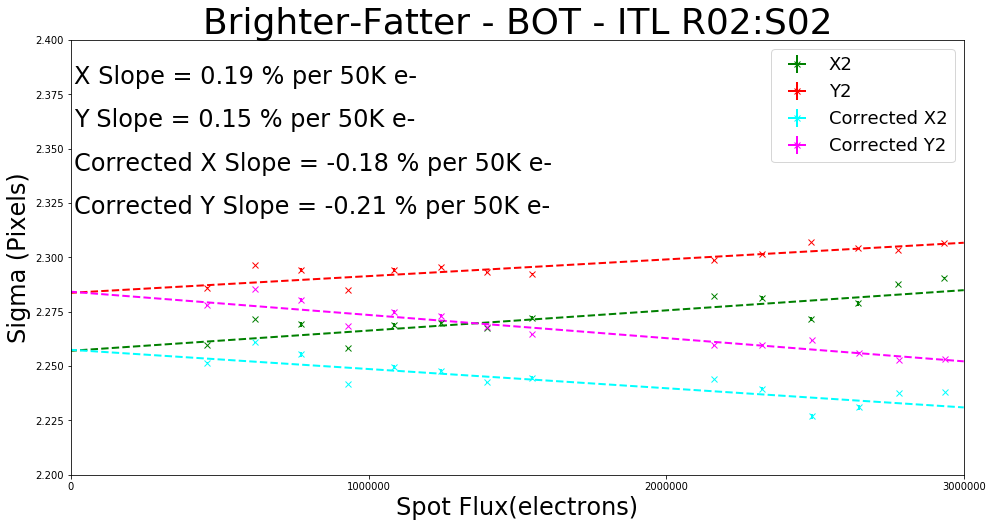

In [53]:
#filename = OUTPUT_DIR+"/spots_results_two_forward.pkl"
#with open(filename, 'rb') as f:
#    spots_pickle= pkl.load(f)
#byamp_results = spots_pickle['results']
#if plotCorrection:
#    byamp_corrected_results = spots_pickle['corrected_results']

# Now plot the result
from scipy import stats
plotCorrection=True
syst_fraction = 0.25
min_slope_index = 2
max_slope_index = len(byamp_results) - 1
max_flux_index = len(byamp_results)
minSpot = 2.2
maxSpot = 2.4
textDelta = (maxSpot - minSpot) / 10
# These next are in case not all fluxes produced good results

try:
    results = np.array([byamp_results[i] for i in range(max_flux_index)])
    max_slope_ind = max_slope_index
except:
    results = np.array(byamp_results)
    max_slope_ind = min(len(results) - 4, max_slope_index)
xerror = results[:,2]/np.sqrt(results[:,0])
xyerror = results[:,4] * (syst_fraction + (1 - syst_fraction) / np.sqrt(results[:,0]))
yyerror = results[:,6] * (syst_fraction + (1 - syst_fraction) / np.sqrt(results[:,0]))

if plotCorrection:
    try:
        corrected_results = np.array([byamp_corrected_results[i] for i in range(max_flux_index)])
        max_slope_ind_corr = max_slope_index
    except:
        corrected_results = np.array(byamp_corrected_results)           
        max_slope_ind_corr = min(len(corrected_results) - 4, max_slope_index)

    corrected_xerror = corrected_results[:,2]/np.sqrt(corrected_results[:,0])
    corrected_xyerror = corrected_results[:,4] * (syst_fraction + (1 - syst_fraction) / np.sqrt(corrected_results[:,0]))
    corrected_yyerror = corrected_results[:,6] * (syst_fraction + (1 - syst_fraction) / np.sqrt(corrected_results[:,0]))

plt.figure(figsize=(16,8))
plt.title("Brighter-Fatter - BOT - ITL R02:S02", fontsize = 36)
# First plot the uncorrected data
plt.errorbar(results[:,1], results[:,3], xerr = xerror, 
             yerr = xyerror, color = 'green', lw = 2, label = 'X2', ls='', marker='x')
plt.errorbar(results[:,1], results[:,5], xerr = xerror, 
             yerr = yyerror, color = 'red', lw = 2, label = 'Y2', ls='',marker='x')
slope, intercept, r_value, p_value, std_err = stats.linregress(results[min_slope_index:max_slope_ind,1], results[min_slope_index:max_slope_ind,3])
xplot=np.linspace(-5000.0,3000000.0,100)
yplot = slope * xplot + intercept
plt.plot(xplot, yplot, color='green', lw = 2, ls = '--')
tslope = slope * 100.0 * 200000.0
plt.text(10000.0,maxSpot-textDelta,"X Slope = %.2f %% per 50K e-"%tslope, fontsize=24)

slope, intercept, r_value, p_value, std_err = stats.linregress(results[min_slope_index:max_slope_ind,1], results[min_slope_index:max_slope_ind,5])
xplot=np.linspace(-5000.0,3000000.0,100)
yplot = slope * xplot + intercept
plt.plot(xplot, yplot, color='red', lw = 2, ls = '--')
tslope = slope * 100.0 * 200000.0
plt.text(10000.0,maxSpot-2*textDelta,"Y Slope = %.2f %% per 50K e-"%tslope, fontsize=24)

if plotCorrection:
    # Now plot the corrected data
    plt.errorbar(corrected_results[:,1], corrected_results[:,3], xerr = corrected_xerror, 
                yerr = corrected_xyerror, color = 'cyan', lw = 2, ls='', marker='x', label = 'Corrected X2')
    plt.errorbar(corrected_results[:,1], corrected_results[:,5], xerr = corrected_xerror,
                yerr = corrected_yyerror, color = 'magenta', lw = 2, ls='', marker='x', label = 'Corrected Y2')
    slope, intercept, r_value, p_value, std_err = stats.linregress(corrected_results[min_slope_index:max_slope_ind_corr,1], corrected_results[min_slope_index:max_slope_ind_corr,3])
    xplot=np.linspace(-5000.0,3000000.0,100)
    yplot = slope * xplot + intercept
    plt.plot(xplot, yplot, color='cyan', lw = 2, ls = '--')
    tslope = slope * 100.0 * 200000.0
    plt.text(10000.0,maxSpot-3*textDelta,"Corrected X Slope = %.2f %% per 50K e-"%tslope, fontsize=24)

    slope, intercept, r_value, p_value, std_err = stats.linregress(corrected_results[min_slope_index:max_slope_ind_corr,1], corrected_results[min_slope_index:max_slope_ind_corr,5])
    xplot=np.linspace(-5000.0,3000000.0,100)
    yplot = slope * xplot + intercept
    plt.plot(xplot, yplot, color='magenta', lw = 2, ls = '--')
    tslope = slope * 100.0 * 200000.0
    plt.text(10000.0,maxSpot-4*textDelta,"Corrected Y Slope = %.2f %% per 50K e-"%tslope, fontsize=24)

plt.xlim(0.0,3000000.0)
plt.xticks([0,1000000,2000000,3000000])
plt.ylim(minSpot, maxSpot)
plt.xlabel('Spot Flux(electrons)',fontsize=24)
plt.ylabel('Sigma (Pixels)',fontsize=24)
plt.legend(loc= 'upper right',fontsize = 18)
plt.savefig(OUTPUT_DIR+"plots_forward/BF_Slopes_Two_Forward_10Jan20.pdf")
